# Structural comparison with TM-align

Compare **one reference structure** against **all structures in a target folder** using
[`tmtools`](https://pypi.org/project/tmtools/) (a Python wrapper around TM-align).

Each file is assumed to contain a **single chain** (e.g. structures prepared from SAbDab).
The notebook reads the first chain of each file, runs TM-align, and collects the results
into a table you can sort, save, and plot.


## 1. Setup

Run this once in your environment (skip if already installed):

```
pip install tmtools biopython pandas matplotlib
```


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tmtools import tm_align
from tmtools.io import get_structure, get_residue_data

## 2. Configure your folders

- `REF_DIR`  : folder holding your **single reference** structure
- `TARGET_DIR` : folder holding the **structures to compare against** (e.g. 10 of them)

Edit the two paths below to point at your data.


In [2]:
REF_DIR    = Path('data/input_vhh')   # folder with your one reference structure
TARGET_DIR = Path('data/target_vhh')   # folder with the structures to compare against

# Find structure files (.pdb or .cif) in each folder
def find_structures(folder):
    return sorted([*folder.glob('*.pdb')])

ref_files = find_structures(REF_DIR)
assert ref_files, f'No .pdb/.cif files found in {REF_DIR}'
REF = ref_files[0]

targets = find_structures(TARGET_DIR)
assert targets, f'No .pdb/.cif files found in {TARGET_DIR}'

print('Reference:', REF.name)
print(f'Targets:   {len(targets)} structures')


Reference: 4s11.pdb
Targets:   10 structures


## 3. Helper to load a structure

Reads the first chain of a file and returns its coordinates and sequence.
(Assumes one chain per file.)


In [3]:
def load(path):
    chain = next(get_structure(str(path)).get_chains())
    coords, seq = get_residue_data(chain)
    return np.ascontiguousarray(coords, dtype=np.float64), seq

## 4. Run the comparison loop

The reference is loaded once, then compared against every target.
Each comparison is wrapped in `try/except` so a single unreadable file just gets
skipped with a warning instead of stopping the whole run.

**Why two TM-scores?** TM-score is not symmetric. Because the reference is always
structure 1, `TM (norm. by reference)` uses the *same denominator* for every target,
which makes it the fair column for **ranking** targets against your reference.


In [9]:
ref_coords, ref_seq = load(REF)
_c, _s = load(targets[0])
print(_c.dtype, len(_s))   # expect: float64 119

rows = []
for t in targets:
    try:
        t_coords, t_seq = load(t)
        res = tm_align(ref_coords, t_coords, ref_seq, t_seq)
        rows.append({
            'target': t.name,
            'target_len': len(t_seq),
            'TM (norm. by reference)': round(res.tm_norm_chain1, 4),
            'TM (norm. by target)':    round(res.tm_norm_chain2, 4),
            'RMSD (A)':                round(res.rmsd, 3),
        })
    except Exception as e:
        print(f'  [skipped] {t.name}: {e}')

df = (pd.DataFrame(rows)
        .sort_values('TM (norm. by reference)', ascending=False)
        .reset_index(drop=True))
df


float64 119


,target,target_len,TM (norm. by reference),TM (norm. by target),RMSD (A)
0,4s11.pdb,129,1.0000,1.0000,0.000
1,6jb9.pdb,128,0.8873,0.8937,1.775
2,6ru3.pdb,124,0.8807,0.9141,1.497
3,6xxp.pdb,127,0.8804,0.8933,1.653
4,5u64.pdb,127,0.8764,0.8894,1.480
5,1sjx.pdb,119,0.8474,0.9149,1.808
6,4idl.pdb,123,0.8180,0.8554,1.788
7,6apo.pdb,116,0.8070,0.8904,1.597
8,7r20.pdb,118,0.7910,0.8584,2.363
9,7f07.pdb,188,0.4054,0.3059,3.796


## 5. Save the results

Writes the table to a CSV next to the notebook.


In [ ]:
df.to_csv('tm_results.csv', index=False)
print('Saved tm_results.csv')


## 6. Quick plot

Bar chart of each target's TM-score (normalized by the reference).
The dashed line marks **0.5**, the rough same-fold threshold.


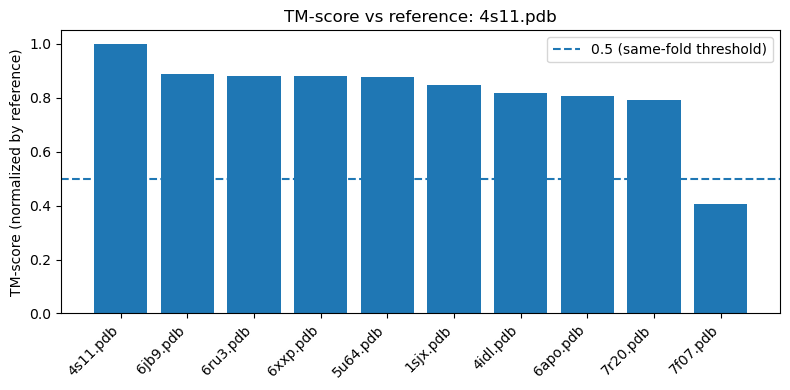

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(df['target'], df['TM (norm. by reference)'])
plt.axhline(0.5, linestyle='--', label='0.5 (same-fold threshold)')
plt.ylabel('TM-score (normalized by reference)')
plt.title(f'TM-score vs reference: {REF.name}')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


## How to read the numbers

| TM-score | meaning |
|---|---|
| > 0.5 | the two structures very likely share the same fold |
| 0.2 - 0.5 | partial / ambiguous similarity |
| < 0.2 | essentially unrelated |

**RMSD** is the deviation (in Angstroms) over the aligned region; lower means a tighter overlap.
